In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense, Activation, Dropout, Conv2D, MaxPooling2D, BatchNormalization, Flatten, Input, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model, load_model, Sequential
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from matplotlib.pyplot import imshow
import os
import seaborn as sns
sns.set_style('darkgrid')
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display, HTML

C:\Users\dragon\anaconda3\envs\CNN-1\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [2]:
sdir = r'C:\Users\dragon\Documents\A Jupyter CNN\uji coba\dataset-1'

In [3]:
filepaths = []
labels = []
classlist = os.listdir(sdir)
print(f"Found classes: {classlist}")

for klass in classlist:
    classpath = os.path.join(sdir, klass)
    if os.path.isdir(classpath):
        flist = os.listdir(classpath)
        print(f"Class '{klass}' has {len(flist)} images")
        for f in flist:
            fpath = os.path.join(classpath, f)
            filepaths.append(fpath)
            labels.append(klass)                   

Fseries = pd.Series(filepaths, name='filepaths')
Lseries = pd.Series(labels, name='labels')    
df = pd.concat([Fseries, Lseries], axis=1)
print(df.head())
print(df['labels'].value_counts())

Found classes: ['NO', 'YES']
Class 'NO' has 800 images
Class 'YES' has 800 images
                                           filepaths labels
0  C:\Users\dragon\Documents\A Jupyter CNN\uji co...     NO
1  C:\Users\dragon\Documents\A Jupyter CNN\uji co...     NO
2  C:\Users\dragon\Documents\A Jupyter CNN\uji co...     NO
3  C:\Users\dragon\Documents\A Jupyter CNN\uji co...     NO
4  C:\Users\dragon\Documents\A Jupyter CNN\uji co...     NO
labels
NO     800
YES    800
Name: count, dtype: int64


In [4]:
train_split = 0.7
test_split = 0.15
dummy_split = test_split / (1 - train_split)

train_df, dummy_df = train_test_split(
    df,
    train_size=train_split,
    shuffle=True,
    random_state=123,
    stratify=df['labels']
)

test_df, valid_df = train_test_split(
    dummy_df,
    train_size=dummy_split,
    shuffle=True,
    random_state=123,
    stratify=dummy_df['labels']
)

print(
    'train_df length:', len(train_df),
    '  test_df length:', len(test_df),
    '  valid_df length:', len(valid_df)
)


train_df length: 1120   test_df length: 239   valid_df length: 241


In [5]:
height = 128
width = 128
channels = 3  # Meskipun gambar grayscale, kita convert ke RGB untuk VGG16
batch_size = 32  # Reduced batch size for better training stability

img_shape = (height, width, channels)
img_size = (height, width)
length = len(test_df)
test_batch_size = sorted([int(length/n) for n in range(1, length+1) if length % n == 0 and length/n <= 80], reverse=True)[0]  
test_steps = int(length / test_batch_size)
print('test batch size:', test_batch_size, '  test steps:', test_steps)

test batch size: 1   test steps: 239


In [6]:
train_gen_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2]
)

train_gen = train_gen_data.flow_from_dataframe(
    train_df, 
    x_col='filepaths', 
    y_col='labels', 
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb',  # Convert grayscale to RGB for VGG16
    shuffle=True, 
    batch_size=batch_size
)

Found 1120 validated image filenames belonging to 2 classes.


In [7]:
valid_gen_data = ImageDataGenerator(rescale=1./255)
valid_gen = valid_gen_data.flow_from_dataframe(
    valid_df, 
    x_col='filepaths', 
    y_col='labels', 
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=True, 
    batch_size=batch_size
)

Found 241 validated image filenames belonging to 2 classes.


In [8]:
test_gen_data = ImageDataGenerator(rescale=1./255)
test_gen = test_gen_data.flow_from_dataframe(
    test_df, 
    x_col='filepaths', 
    y_col='labels', 
    target_size=img_size, 
    class_mode='categorical',
    color_mode='rgb', 
    shuffle=False, 
    batch_size=test_batch_size
)

classes = list(train_gen.class_indices.keys())
print("Classes:", classes)
class_count = len(classes)

Found 239 validated image filenames belonging to 2 classes.
Classes: ['NO', 'YES']


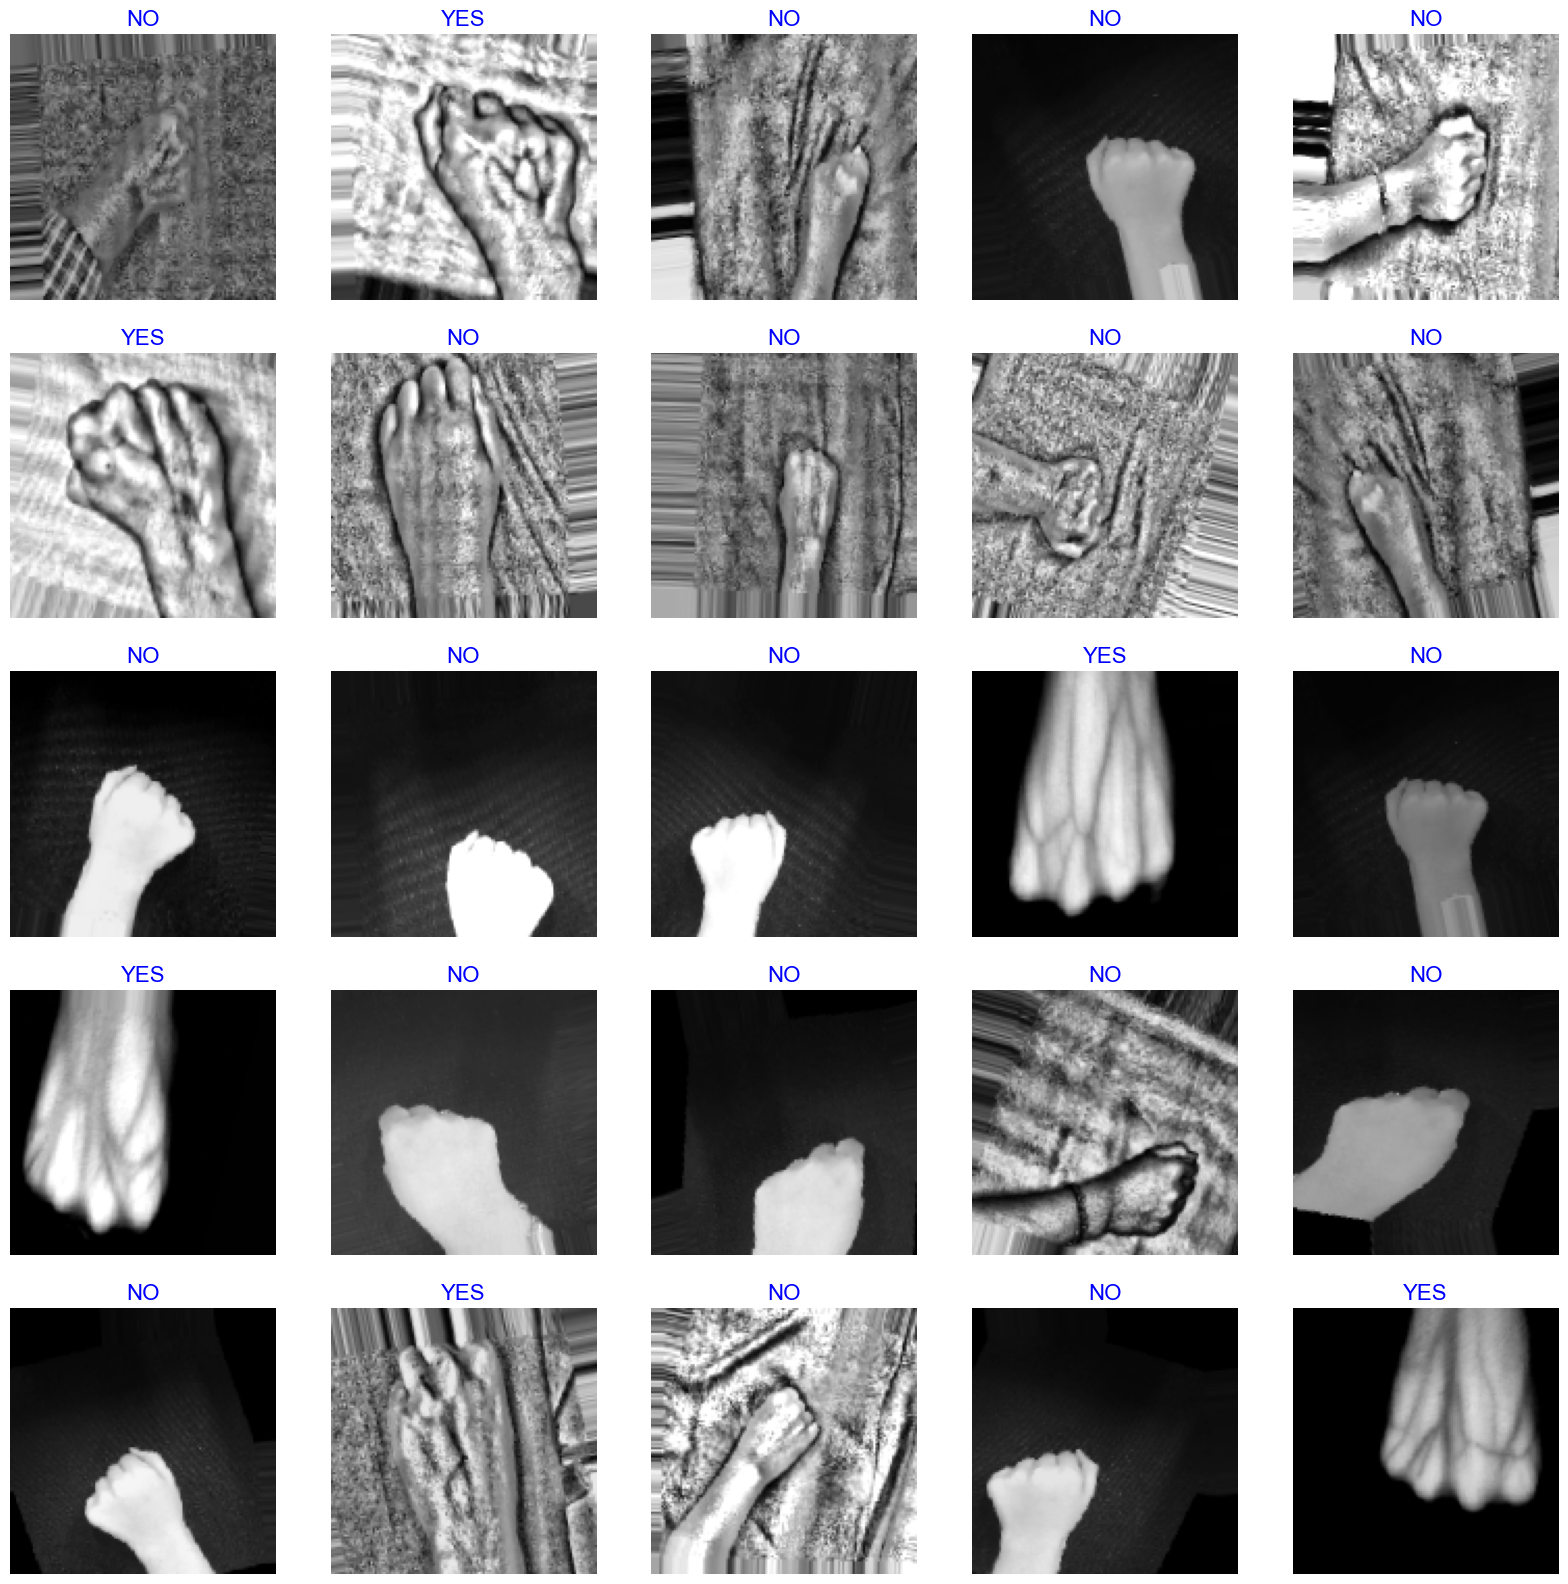

In [9]:
def show_image_samples(gen):
    test_dict = gen.class_indices
    classes = list(test_dict.keys())    
    images, labels = next(gen)  # get a sample batch from the generator 
    plt.figure(figsize=(20, 20))
    length = len(labels)
    if length < 25:   # show maximum of 25 images
        r = length
    else:
        r = 25
    for i in range(r):
        plt.subplot(5, 5, i + 1)
        image = images[i]
        plt.imshow(image)
        index = np.argmax(labels[i])
        class_name = classes[index]
        plt.title(class_name, color='blue', fontsize=16)
        plt.axis('off')
    plt.show()

show_image_samples(train_gen)

In [10]:
base_model = tf.keras.applications.VGG16(
    include_top=False, 
    weights="imagenet",
    input_tensor=Input(shape=(128, 128, 3))
) 
base_model.summary()



Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 128, 128, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 128, 128, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 64, 64, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 64, 64, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 64, 64, 128)       147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 32, 32, 128)       0   

In [11]:
base_model.trainable = False

model_name = 'VeinDetection'
print("Building model with", base_model)

Building model with <keras.src.engine.functional.Functional object at 0x000002B0B9A61330>


In [12]:
model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),  # Better than Flatten for transfer learning
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(rate=0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(rate=0.3),
    tf.keras.layers.Dense(len(classes), activation='softmax')
])

In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), 
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 4, 4, 512)         14714688  
                                                                 
 global_average_pooling2d (  (None, 512)               0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 512)               262656    
                                                                 
 batch_normalization (Batch  (None, 512)               2048      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               1

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(
        filepath='best_vein_model.keras', 
        monitor='val_accuracy', 
        save_best_only=True, 
        verbose=1
    )
]

import warnings
warnings.filterwarnings('ignore', category=UserWarning)

epochs = 20

In [15]:
history = model.fit(
    x=train_gen, 
    epochs=epochs, 
    validation_data=valid_gen,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


35/35 [==============================] - ETA: 0s - loss: 0.4149 - accuracy: 0.8455
Epoch 1: val_accuracy improved from -inf to 0.72199, saving model to best_vein_model.keras
35/35 [==============================] - 327s 9s/step - loss: 0.4149 - accuracy: 0.8455 - val_loss: 0.4891 - val_accuracy: 0.7220 - lr: 0.0010
Epoch 2/20
35/35 [==============================] - ETA: 0s - loss: 0.2977 - accuracy: 0.9027
Epoch 2: val_accuracy improved from 0.72199 to 0.73859, saving model to best_vein_model.keras
35/35 [==============================] - 344s 10s/step - loss: 0.2977 - accuracy: 0.9027 - val_loss: 0.4450 - val_accuracy: 0.7386 - lr: 0.0010
Epoch 3/20
35/35 [==============================] - ETA: 0s - loss: 0.2026 - accuracy: 0.9205
Epoch 3: val_accuracy improved from 0.73859 to 0.78838, saving model to best_vein_model.keras
35/35 [==============================] - 293s 8s/step - loss: 0.2026 - accuracy: 0.9205 - val_loss: 0.3494 - val_accuracy: 0.7884 - lr: 0.0010
Epoch 4

In [16]:
def print_in_color(txt_msg, fore_tupple, back_tupple):
    rf, gf, bf = fore_tupple
    rb, gb, bb = back_tupple
    msg = '{0}' + txt_msg
    mat = '\33[38;2;' + str(rf) + ';' + str(gf) + ';' + str(bf) + ';48;2;' + str(rb) + ';' + str(gb) + ';' + str(bb) + 'm' 
    print(msg.format(mat), flush=True)
    print('\33[0m', flush=True)
    return

In [17]:
def tr_plot(tr_data, start_epoch):
    tacc = tr_data.history['accuracy']
    tloss = tr_data.history['loss']
    vacc = tr_data.history['val_accuracy']
    vloss = tr_data.history['val_loss']
    Epoch_count = len(tacc) + start_epoch
    Epochs = []
    for i in range(start_epoch, Epoch_count):
        Epochs.append(i + 1)   
    index_loss = np.argmin(vloss)
    val_lowest = vloss[index_loss]
    index_acc = np.argmax(vacc)
    acc_highest = vacc[index_acc]
    plt.style.use('fivethirtyeight')
    sc_label = 'best epoch= ' + str(index_loss + 1 + start_epoch)
    vc_label = 'best epoch= ' + str(index_acc + 1 + start_epoch)
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))
    axes[0].plot(Epochs, tloss, 'r', label='Training loss')
    axes[0].plot(Epochs, vloss, 'g', label='Validation loss')
    axes[0].scatter(index_loss + 1 + start_epoch, val_lowest, s=150, c='blue', label=sc_label)
    axes[0].set_title('Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[1].plot(Epochs, tacc, 'r', label='Training Accuracy')
    axes[1].plot(Epochs, vacc, 'g', label='Validation Accuracy')
    axes[1].scatter(index_acc + 1 + start_epoch, acc_highest, s=150, c='blue', label=vc_label)
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()

In [18]:
def print_info(test_gen, preds, print_code, save_dir, subject):
    class_dict = test_gen.class_indices
    labels = test_gen.labels
    file_names = test_gen.filenames 
    error_list = []
    true_class = []
    pred_class = []
    prob_list = []
    new_dict = {}
    error_indices = []
    y_pred = []
    
    for key, value in class_dict.items():
        new_dict[value] = key
    
    classes = list(new_dict.values())
    dict_as_text = str(new_dict)
    dict_name = subject + '-' + str(len(classes)) + '.txt'  
    dict_path = os.path.join(save_dir, dict_name)    
    with open(dict_path, 'w') as x_file:
        x_file.write(dict_as_text)    
    
    errors = 0      
    for i, p in enumerate(preds):
        pred_index = np.argmax(p)        
        true_index = labels[i]
        if pred_index != true_index:
            error_list.append(file_names[i])
            true_class.append(new_dict[true_index])
            pred_class.append(new_dict[pred_index])
            prob_list.append(p[pred_index])
            error_indices.append(true_index)            
            errors = errors + 1
        y_pred.append(pred_index)    
    
    if print_code != 0:
        if errors > 0:
            if print_code > errors:
                r = errors
            else:
                r = print_code           
            msg = '{0:^28s}{1:^28s}{2:^28s}{3:^16s}'.format('Filename', 'Predicted Class', 'True Class', 'Probability')
            print_in_color(msg, (0, 255, 0), (55, 65, 80))
            for i in range(r):                
                split1 = os.path.split(error_list[i])                
                split2 = os.path.split(split1[0])                
                fname = split2[1] + '/' + split1[1]
                msg = '{0:^28s}{1:^28s}{2:^28s}{3:4s}{4:^6.4f}'.format(fname, pred_class[i], true_class[i], ' ', prob_list[i])
                print_in_color(msg, (255, 255, 255), (55, 65, 60))
        else:
            msg = 'With accuracy of 100% there are no errors to print'
            print_in_color(msg, (0, 255, 0), (55, 65, 80))
    
    if errors > 0:
        plot_bar = []
        plot_class = []
        for key, value in new_dict.items():        
            count = error_indices.count(key) 
            if count != 0:
                plot_bar.append(count)
                plot_class.append(value)
        fig = plt.figure()
        fig.set_figheight(len(plot_class) / 3)
        fig.set_figwidth(10)
        plt.style.use('fivethirtyeight')
        for i in range(0, len(plot_class)):
            c = plot_class[i]
            x = plot_bar[i]
            plt.barh(c, x)
            plt.title('Errors by Class on Test Set')
    
    y_true = np.array(labels)        
    y_pred = np.array(y_pred)
    
    if len(classes) <= 30:
        cm = confusion_matrix(y_true, y_pred)        
        length = len(classes)
        if length < 8:
            fig_width = 8
            fig_height = 8
        else:
            fig_width = int(length * 0.5)
            fig_height = int(length * 0.5)
        plt.figure(figsize=(fig_width, fig_height))
        sns.heatmap(cm, annot=True, vmin=0, fmt='g', cmap='Blues', cbar=False)       
        plt.xticks(np.arange(length) + 0.5, classes, rotation=90)
        plt.yticks(np.arange(length) + 0.5, classes, rotation=0)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.title("Confusion Matrix - Vein Detection")
        plt.show()
    
    clr = classification_report(y_true, y_pred, target_names=classes)
    print("Classification Report:\n----------------------\n", clr)

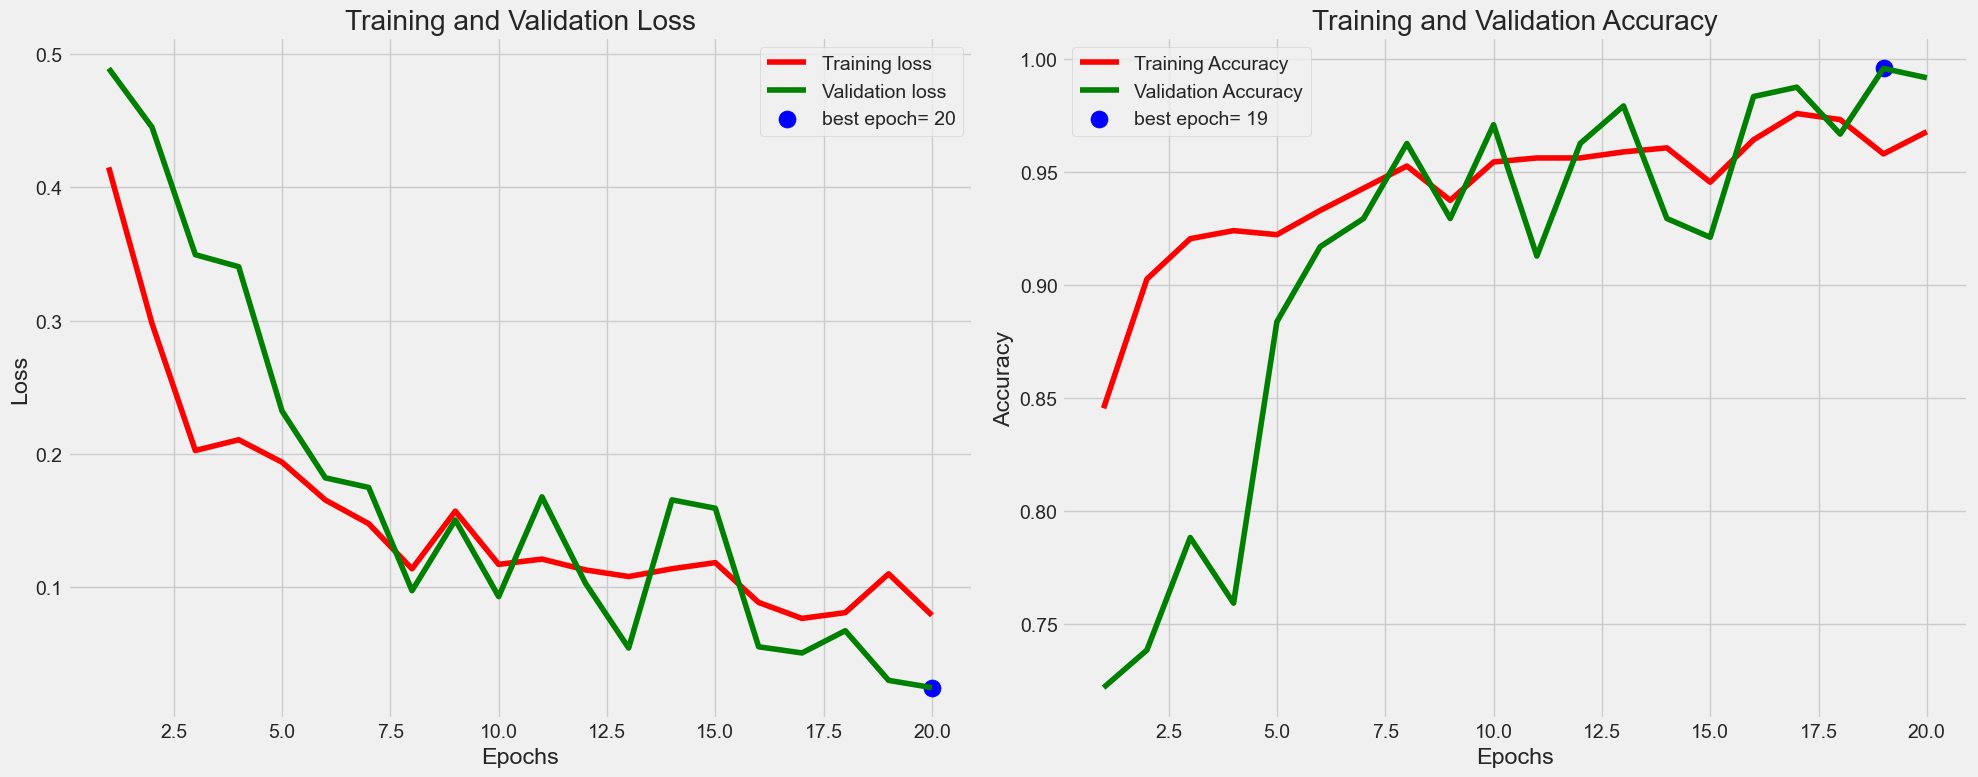

In [19]:
tr_plot(history, 0)
save_dir = r'./'
subject = 'vein_detection'

In [20]:
if os.path.exists('best_vein_model.keras'):
    model = load_model('best_vein_model.keras')
    print("Loaded best model from training")

acc = model.evaluate(test_gen, batch_size=test_batch_size, verbose=1, steps=test_steps, return_dict=False)[1] * 100
msg = f'Accuracy on the test set is {acc:5.2f}%'
print_in_color(msg, (0, 255, 0), (55, 65, 80))

save_id = str(model_name + '-' + subject + '-' + str(acc)[:str(acc).rfind('.') + 3] + '.keras')
save_loc = os.path.join(save_dir, save_id)
model.save(save_loc)
print(f"Model saved as: {save_id}")

Loaded best model from training
239/239 [==============================] - 107s 399ms/step - loss: 0.0470 - accuracy: 0.9791
Accuracy on the test set is 97.91%

Model saved as: VeinDetection-vein_detection-97.90.keras


239/239 [==============================] - 60s 226ms/step


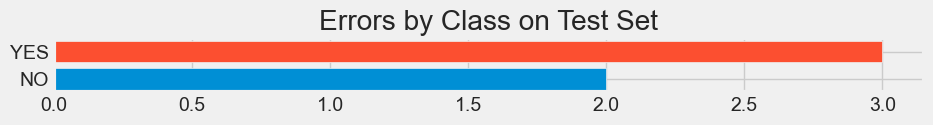

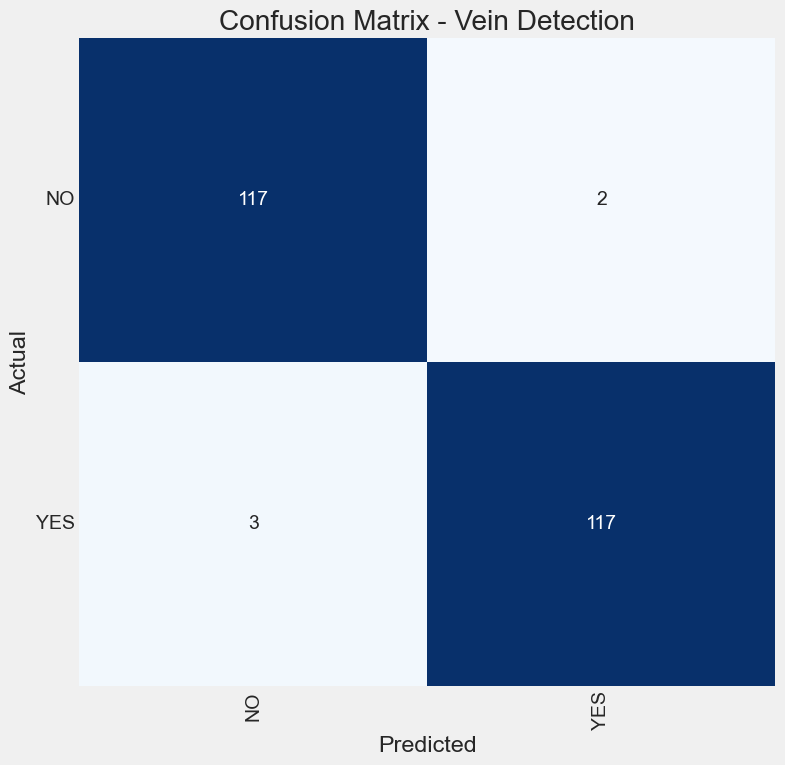

Classification Report:
----------------------
               precision    recall  f1-score   support

          NO       0.97      0.98      0.98       119
         YES       0.98      0.97      0.98       120

    accuracy                           0.98       239
   macro avg       0.98      0.98      0.98       239
weighted avg       0.98      0.98      0.98       239



In [21]:
print_code = 0
preds = model.predict(test_gen) 
print_info(test_gen, preds, print_code, save_dir, subject)